In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
print('Libraries loaded successfully')

Libraries loaded successfully


In [2]:
df = pd.read_csv('../data/Indian_Online_Scam_Dataset.csv')
print('Shape:', df.shape)
df.head(10)

Shape: (7953, 11)


,transaction_id,customer_id,merchant_id,amount,transaction_time,is_fraudulent,card_type,location,purchase_category,customer_age,fraud_type
0,1.0,684415.0,2028.0,1262.770,11/24/2023 22:39,0.0,Rupay,Bangalore,NaN,28.0,Identity theft
1,2.0,447448.0,2046.0,2222.928,03/30/2024 16:18,0.0,MasterCard,Surat,POS,62.0,Malware
2,3.0,975001.0,2067.0,7509.832,03-07-2024 18:27,0.0,MasterCard,Hyderabad,POS,24.0,Malware
3,4.0,976547.0,NaN,2782.965,02-01-2024 00:58,0.0,Rupay,Hyderabad,Digital,62.0,Payment card fraud
4,5.0,935741.0,2044.0,NaN,12/22/2023 18:42,0.0,NaN,Bangalore,Digital,19.0,scam
5,6.0,774817.0,2001.0,8526.012,03-04-2024 22:33,1.0,Rupay,Mumbai,NaN,23.0,scam
6,7.0,957795.0,2026.0,1224.773,NaN,0.0,Visa,Surat,Digital,58.0,scam
7,8.0,266812.0,2094.0,9396.354,09-08-2023 01:13,0.0,NaN,Mumbai,POS,49.0,Payment card fraud
8,9.0,401388.0,2035.0,3904.200,01-09-2024 00:43,0.0,Visa,Kolkata,Digital,37.0,Malware
9,NaN,602861.0,2035.0,NaN,03-08-2024 08:17,0.0,MasterCard,Ahmedabad,POS,51.0,Identity theft


In [3]:
print('=== Data Types ===')
print(df.dtypes)
print()
print('=== Basic Stats ===')
df.describe()

=== Data Types ===
transaction_id       float64
customer_id          float64
merchant_id          float64
amount               float64
transaction_time         str
is_fraudulent        float64
card_type                str
location                 str
purchase_category        str
customer_age         float64
fraud_type               str
dtype: object

=== Basic Stats ===


,transaction_id,customer_id,merchant_id,amount,is_fraudulent,customer_age
count,7478.000000,7532.000000,7481.00000,7261.00000,7228.000000,7285.000000
mean,600.858786,542464.492034,2049.66181,6149.98508,0.313365,43.361153
std,346.844631,255414.605733,29.08818,3805.09295,0.463893,14.913870
min,1.000000,100184.000000,2000.00000,84.71100,0.000000,18.000000
25%,296.000000,317669.000000,2025.00000,3031.60500,0.000000,31.000000
50%,605.500000,552098.000000,2048.00000,5965.04000,0.000000,43.000000
75%,899.750000,763253.000000,2075.00000,8704.22400,1.000000,56.000000
max,1200.000000,998799.000000,2099.00000,17960.97600,1.000000,69.000000


In [4]:
print('=== Null Value Counts ===')
null_counts = df.isnull().sum()
null_pct = (df.isnull().sum() / len(df) * 100).round(2)
null_df = pd.DataFrame({'Null Count': null_counts, 'Null %': null_pct})
print(null_df[null_df['Null Count'] > 0])

=== Null Value Counts ===
                   Null Count  Null %
transaction_id            475    5.97
customer_id               421    5.29
merchant_id               472    5.93
amount                    692    8.70
transaction_time          568    7.14
is_fraudulent             725    9.12
card_type                 567    7.13
location                  523    6.58
purchase_category         532    6.69
customer_age              668    8.40
fraud_type                498    6.26


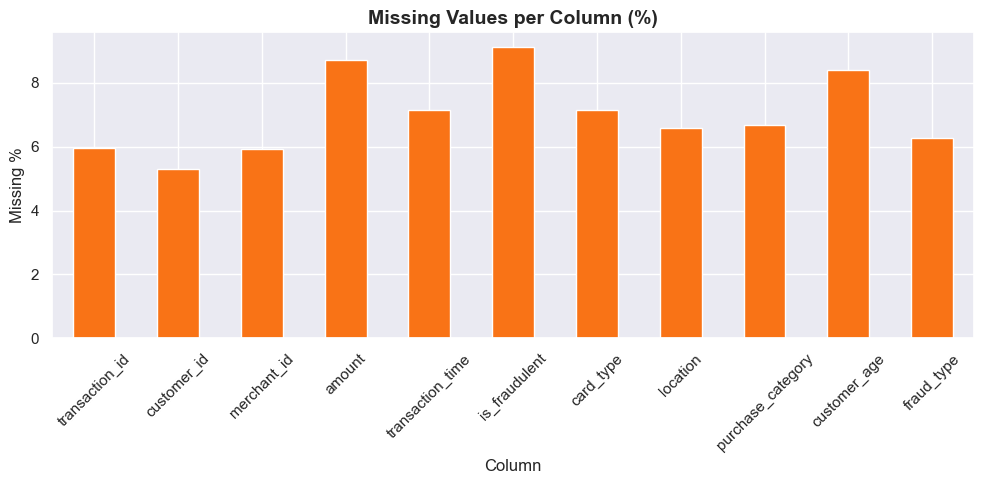

In [5]:
fig, ax = plt.subplots(figsize=(10, 5))
null_pct[null_pct > 0].plot(kind='bar', color='#f97316', ax=ax)
ax.set_title('Missing Values per Column (%)', fontsize=14, fontweight='bold')
ax.set_ylabel('Missing %')
ax.set_xlabel('Column')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

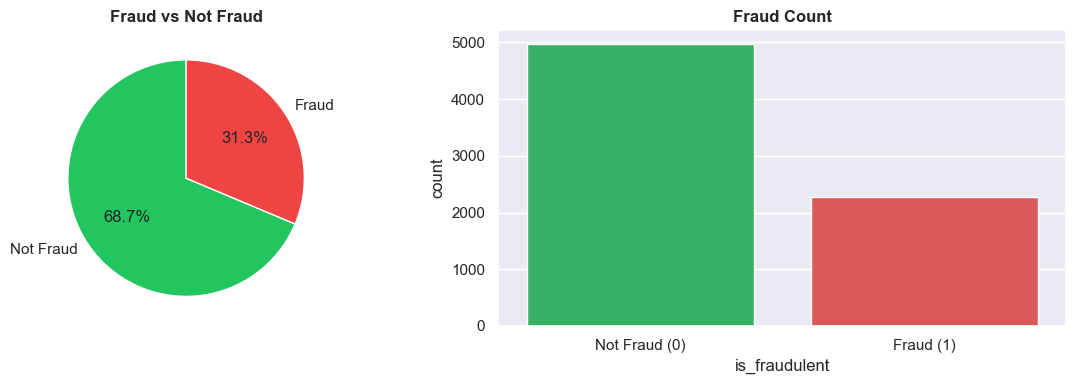

is_fraudulent
0.0    4963
1.0    2265
Name: count, dtype: int64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

fraud_counts = df['is_fraudulent'].value_counts()
axes[0].pie(fraud_counts, labels=['Not Fraud', 'Fraud'], autopct='%1.1f%%',
            colors=['#22c55e', '#ef4444'], startangle=90)
axes[0].set_title('Fraud vs Not Fraud', fontweight='bold')

sns.countplot(data=df, x='is_fraudulent', palette=['#22c55e', '#ef4444'], ax=axes[1])
axes[1].set_title('Fraud Count', fontweight='bold')
axes[1].set_xticklabels(['Not Fraud (0)', 'Fraud (1)'])

plt.tight_layout()
plt.show()
print(fraud_counts)

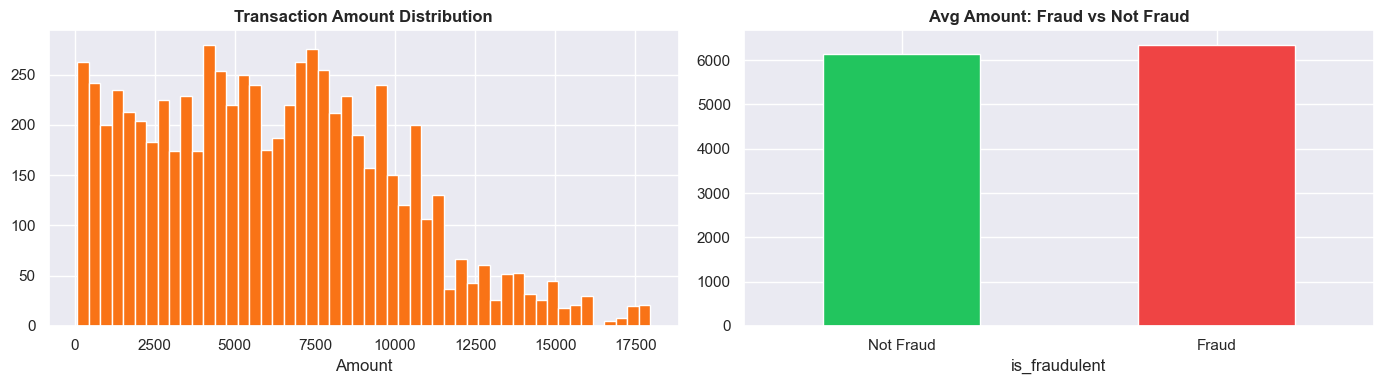

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['amount'].dropna().hist(bins=50, color='#f97316', ax=axes[0])
axes[0].set_title('Transaction Amount Distribution', fontweight='bold')
axes[0].set_xlabel('Amount')

df.groupby('is_fraudulent')['amount'].mean().plot(kind='bar', color=['#22c55e', '#ef4444'], ax=axes[1])
axes[1].set_title('Avg Amount: Fraud vs Not Fraud', fontweight='bold')
axes[1].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)

plt.tight_layout()
plt.show()

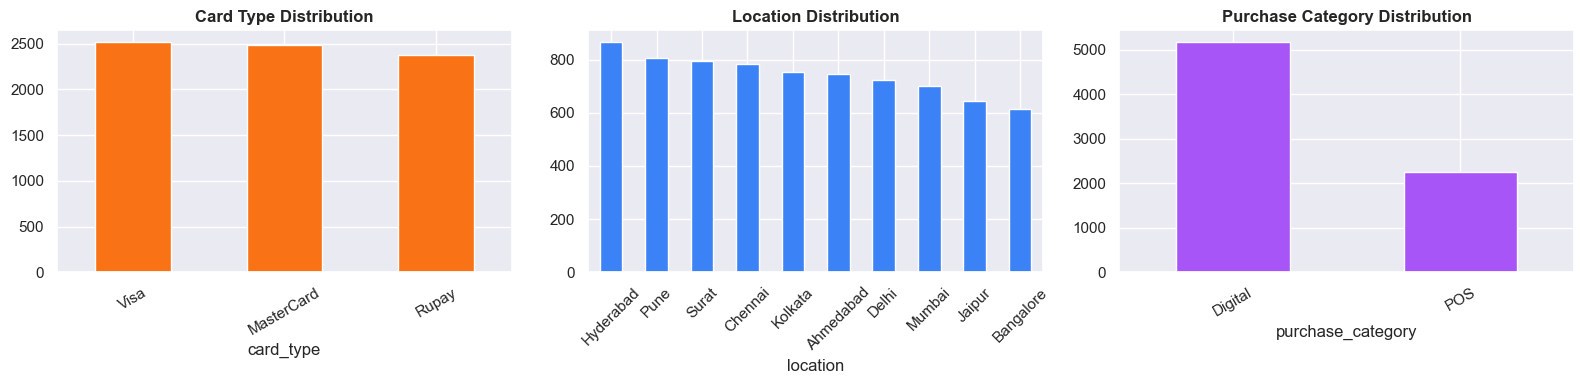

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df['card_type'].value_counts().plot(kind='bar', color='#f97316', ax=axes[0])
axes[0].set_title('Card Type Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

df['location'].value_counts().plot(kind='bar', color='#3b82f6', ax=axes[1])
axes[1].set_title('Location Distribution', fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)

df['purchase_category'].value_counts().plot(kind='bar', color='#a855f7', ax=axes[2])
axes[2].set_title('Purchase Category Distribution', fontweight='bold')
axes[2].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

In [9]:
print('Shape before cleaning:', df.shape)

df = df.drop(columns=['fraud_type'])
print('Columns after dropping:', df.columns.tolist())

# Drop rows where target is null
df = df.dropna(subset=['is_fraudulent'])
print('Shape after dropping null target rows:', df.shape)

Shape before cleaning: (7953, 11)
Columns after dropping: ['transaction_id', 'customer_id', 'merchant_id', 'amount', 'transaction_time', 'is_fraudulent', 'card_type', 'location', 'purchase_category', 'customer_age']
Shape after dropping null target rows: (7228, 10)


In [10]:
# Numeric — fill with median
df['amount']       = df['amount'].fillna(df['amount'].median())
df['customer_age'] = df['customer_age'].fillna(df['customer_age'].median())

# Categorical — fill with mode
df['card_type']         = df['card_type'].fillna(df['card_type'].mode()[0])
df['location']          = df['location'].fillna(df['location'].mode()[0])
df['purchase_category'] = df['purchase_category'].fillna(df['purchase_category'].mode()[0])

print('Null values after cleaning:')
print(df.isnull().sum())
print()
print('Final shape:', df.shape)

Null values after cleaning:
transaction_id       426
customer_id          378
merchant_id          447
amount                 0
transaction_time     508
is_fraudulent          0
card_type              0
location               0
purchase_category      0
customer_age           0
dtype: int64

Final shape: (7228, 10)


In [11]:
# Drop columns not needed for training
df = df.drop(columns=['transaction_id', 'customer_id', 'merchant_id', 'transaction_time'], errors='ignore')

# Encode categorical columns
df = pd.get_dummies(df, columns=['card_type', 'location', 'purchase_category'], drop_first=True)

# Convert all to float
df = df.astype(float)

print('Final columns:', df.columns.tolist())
print('Final shape:', df.shape)
df.head()

Final columns: ['amount', 'is_fraudulent', 'customer_age', 'card_type_Rupay', 'card_type_Visa', 'location_Bangalore', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Jaipur', 'location_Kolkata', 'location_Mumbai', 'location_Pune', 'location_Surat', 'purchase_category_POS']
Final shape: (7228, 15)


,amount,is_fraudulent,customer_age,card_type_Rupay,card_type_Visa,location_Bangalore,location_Chennai,location_Delhi,location_Hyderabad,location_Jaipur,location_Kolkata,location_Mumbai,location_Pune,location_Surat,purchase_category_POS
0,1262.770,0.0,28.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2222.928,0.0,62.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
2,7509.832,0.0,24.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,2782.965,0.0,62.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
4,5993.625,0.0,19.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [12]:
X = df.drop('is_fraudulent', axis=1)
y = df['is_fraudulent']

print('Features shape:', X.shape)
print('Target distribution:', y.value_counts().to_dict())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {len(X_train)} | Test: {len(X_test)}')

Features shape: (7228, 14)
Target distribution: {0.0: 4963, 1.0: 2265}
Train: 5782 | Test: 1446


In [18]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',   # fixes imbalance
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print('Model trained successfully!')

Model trained successfully!


In [19]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print('=== Classification Report ===')
print(classification_report(y_test, y_pred, target_names=['Not Fraud', 'Fraud']))
print('ROC-AUC Score:', round(roc_auc_score(y_test, y_proba), 4))

=== Classification Report ===
              precision    recall  f1-score   support

   Not Fraud       0.95      0.91      0.93       993
       Fraud       0.82      0.90      0.86       453

    accuracy                           0.91      1446
   macro avg       0.89      0.91      0.90      1446
weighted avg       0.91      0.91      0.91      1446

ROC-AUC Score: 0.9702


In [15]:
print(X.columns.tolist())

['amount', 'customer_age', 'card_type_Rupay', 'card_type_Visa', 'location_Bangalore', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Jaipur', 'location_Kolkata', 'location_Mumbai', 'location_Pune', 'location_Surat', 'purchase_category_POS']


In [20]:
os.makedirs('../models', exist_ok=True)
joblib.dump(model, '../models/scam_model.pkl')
joblib.dump(list(X.columns), '../models/scam_features.pkl')

print('Model saved to ../models/scam_model.pkl')
print('Features saved to ../models/scam_features.pkl')
print('Feature columns:', list(X.columns))

Model saved to ../models/scam_model.pkl
Features saved to ../models/scam_features.pkl
Feature columns: ['amount', 'customer_age', 'card_type_Rupay', 'card_type_Visa', 'location_Bangalore', 'location_Chennai', 'location_Delhi', 'location_Hyderabad', 'location_Jaipur', 'location_Kolkata', 'location_Mumbai', 'location_Pune', 'location_Surat', 'purchase_category_POS']
